<a href="https://colab.research.google.com/github/odbayar2/AI-repository/blob/main/24102631_%ED%86%A1%ED%86%A0%ED%9D%90%EB%B0%94%EC%95%BC%EB%A5%B4%20%EC%98%A4%EB%93%9C%EB%B0%94%EC%95%BC%EB%A5%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [TODO]

## Mall custermer data

There is information on the customer's gender, age, and annual revenue, and spending score filled with scores from 1 to 100 on the purchase amount.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/wonseok-hong/DAP_TA/main/Mall_Customers.csv')
df.head()

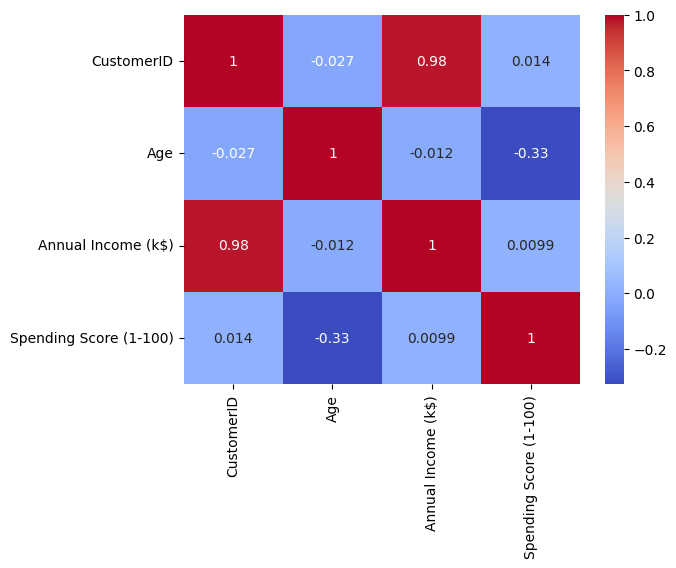

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the DataFrame if not already loaded (to make this cell self-contained)
df = pd.read_csv('https://raw.githubusercontent.com/wonseok-hong/DAP_TA/main/Mall_Customers.csv')

# Select Numeric Values
df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.show()

##Data Preprocessing

We will choose Annual Income (k$), Spending Score (1-100), and Z-score Scaling (by sklearn.preprocessing.StandardScaler)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Choosing
data = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

data.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


## Elbow analysis with K-MEANS

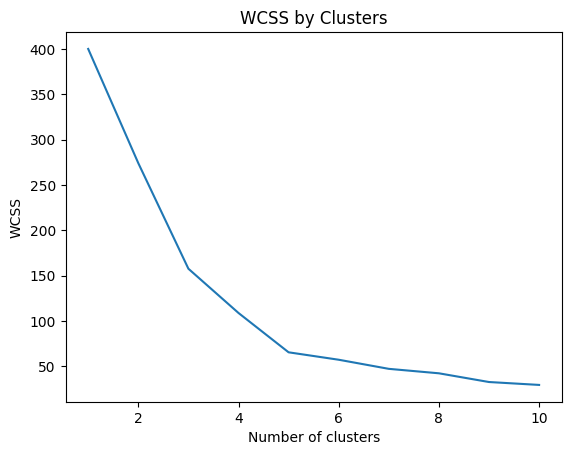

In [8]:
#importing the libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
%matplotlib inline

# Create 10 models with 1 to 10 clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)

    # Fit the data points
    kmeans.fit(data)

    # Get the WCSS (inertia) value
    wcss.append(kmeans.inertia_)

#Plot the WCSS values onto a line graph
plt.plot(range(1, 11), wcss)
plt.title('WCSS by Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

### K-means fitting
- n_clusters = k
- random_state = 0


In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ensure df is loaded (making the cell self-contained)
df = pd.read_csv('https://raw.githubusercontent.com/wonseok-hong/DAP_TA/main/Mall_Customers.csv')

# Prepare data (making the cell self-contained)
scaler = StandardScaler()
data = df[['Annual Income (k$)', 'Spending Score (1-100)']]
data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

k = 3

model = KMeans(n_clusters=k, random_state=0, n_init='auto')

# fitting
model.fit(data)

# predicting
pred = model.predict(data)

df['cluster'] = pred

print("K-Means clustering completed. 'cluster' column added to df.")
# Display the head of df with the new 'cluster' column to confirm
display(df.head())

K-Means clustering completed. 'cluster' column added to df.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


### Full Workflow: Data Loading, Preprocessing, Clustering, and Visualization

This cell combines all the previous steps to ensure proper execution and variable definition throughout the analysis.

1. Loading data...
Original DataFrame head:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



2. Preprocessing data: selecting numeric features and scaling...
Scaled data head:


,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980



3. Performing Elbow Analysis...


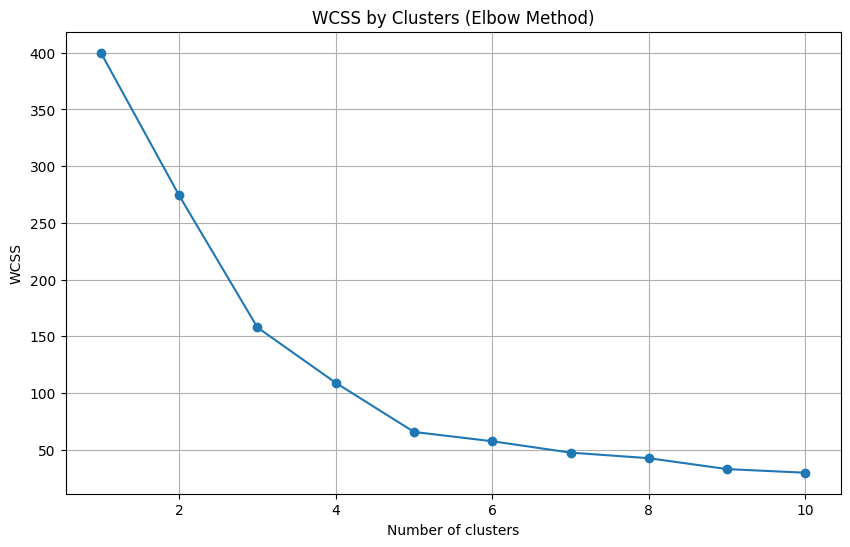


4. Fitting K-Means model with k=3...
Clusters assigned to 200 customers.

5. Calculating Silhouette Score...
Silhouette Coefficient: 0.4666

6. Generating Scatter Plot with Clusters and Centroids...


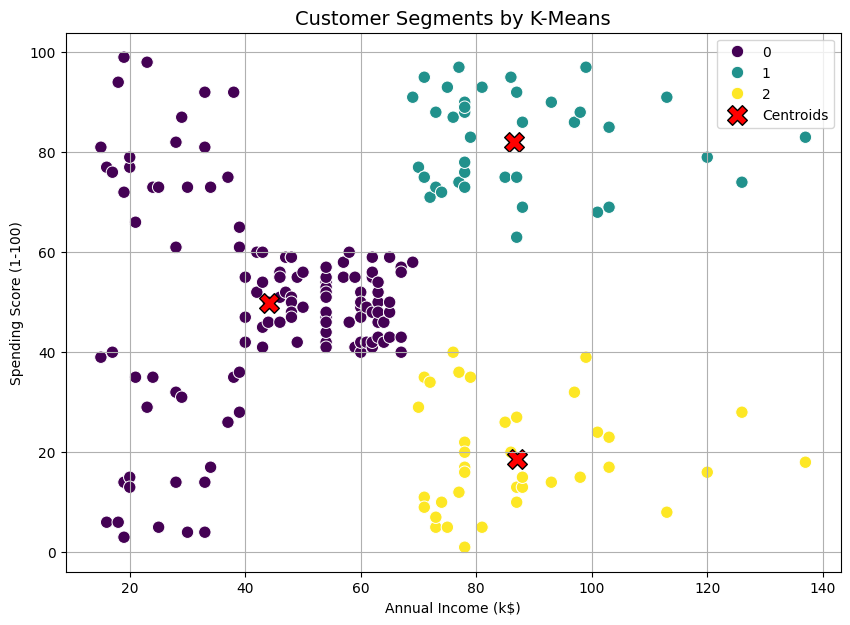


7. Generating Dendrogram for Hierarchical Clustering...


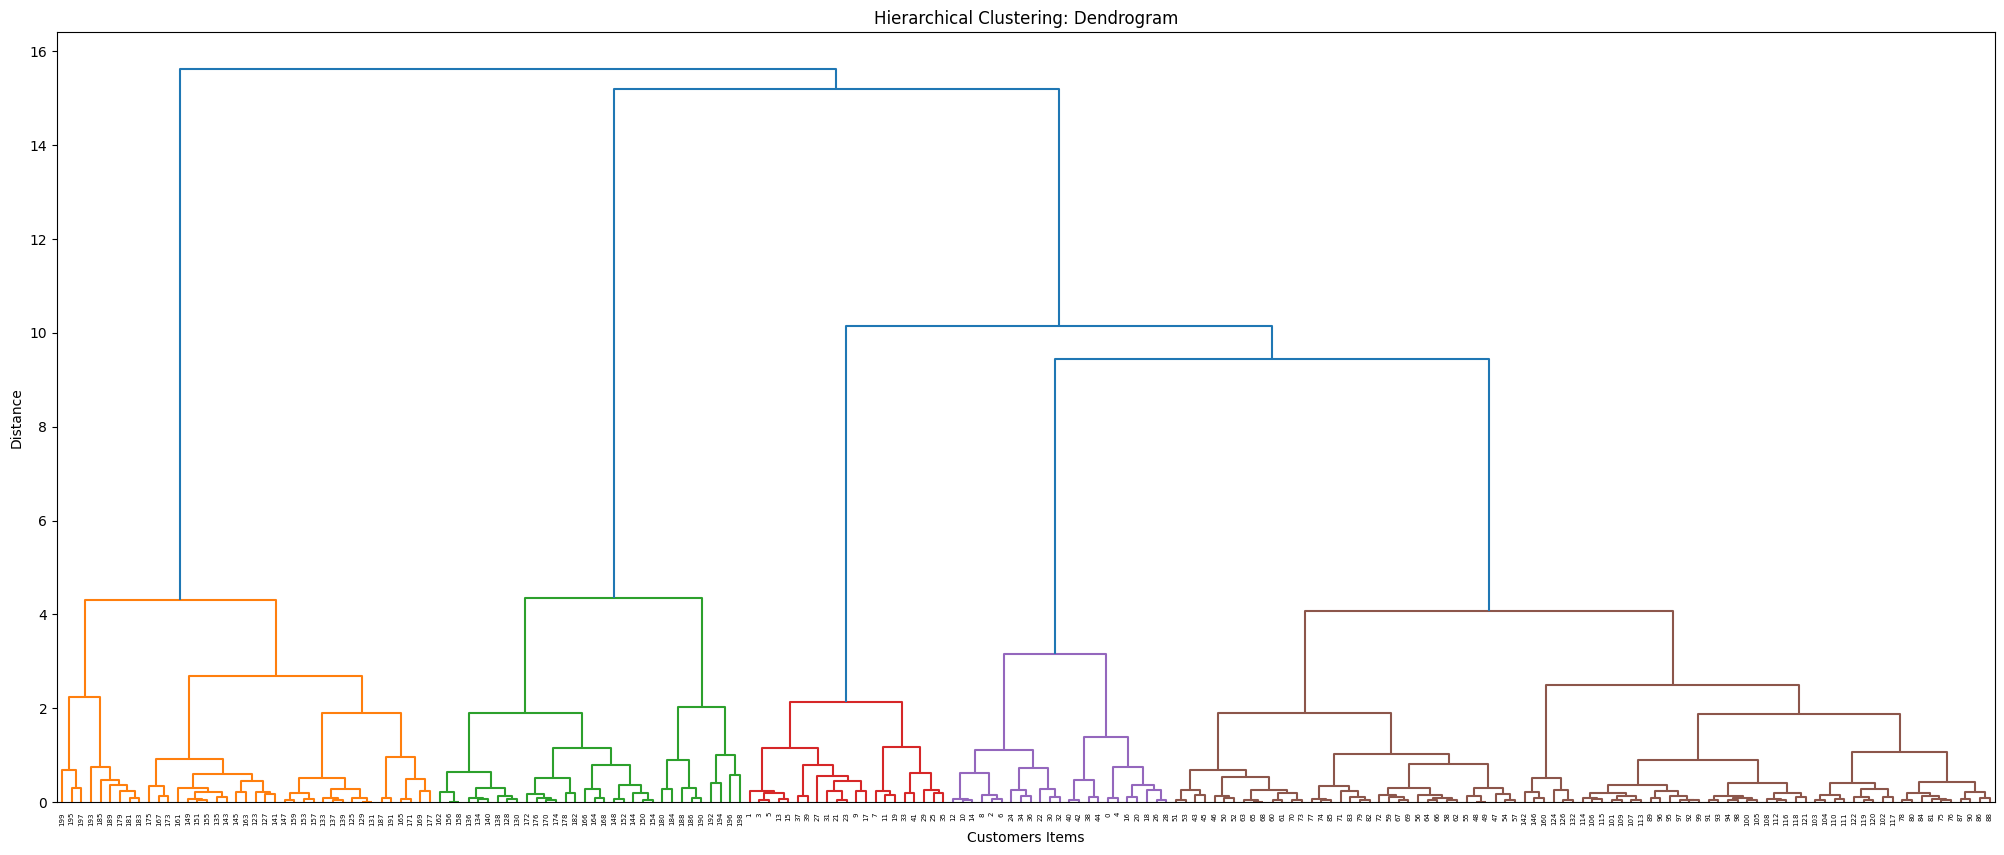


Analysis complete!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Data Loading
print("1. Loading data...")
df = pd.read_csv('https://raw.githubusercontent.com/wonseok-hong/DAP_TA/main/Mall_Customers.csv')
print("Original DataFrame head:")
display(df.head())

# 2. Data Preprocessing (Numeric selection and Scaling)
print("\n2. Preprocessing data: selecting numeric features and scaling...")
df_numeric = df.select_dtypes(include=['int64', 'float64'])
scaler = StandardScaler()
data = df_numeric[['Annual Income (k$)', 'Spending Score (1-100)']]
data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
print("Scaled data head:")
display(data.head())

# 3. Elbow Analysis (Re-running for completeness, though it's already fixed)
print("\n3. Performing Elbow Analysis...")
wcss = []
for i in range(1, 11):
    kmeans_model_elbow = KMeans(n_clusters=i, random_state=0, n_init='auto')
    kmeans_model_elbow.fit(data)
    wcss.append(kmeans_model_elbow.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('WCSS by Clusters (Elbow Method)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# 4. K-Means Fitting
print("\n4. Fitting K-Means model with k=3...")
k = 3
model = KMeans(n_clusters=k, random_state=0, n_init='auto')
model.fit(data)
pred = model.predict(data)
df['cluster'] = pred # Add cluster assignments to original df
print(f"Clusters assigned to {len(df)} customers.")

# 5. Silhouette Score Calculation
print("\n5. Calculating Silhouette Score...")
silhouette_avg = silhouette_score(data, pred)
print(f"Silhouette Coefficient: {silhouette_avg:.4f}")

# 6. Scatter Plot with Cluster Color
print("\n6. Generating Scatter Plot with Clusters and Centroids...")
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='cluster',
    palette='viridis',
    data=df,
    s=80
)

centers_original = scaler.inverse_transform(model.cluster_centers_)
plt.scatter(
    centers_original[:, 0], centers_original[:, 1],
    c='red', s=200, marker='X', edgecolor='black', label='Centroids'
)

plt.title('Customer Segments by K-Means', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

# 7. Dendrogram
print("\n7. Generating Dendrogram for Hierarchical Clustering...")
Z = linkage(data, method='ward')

plt.figure(figsize=(25, 10))
dendrogram(Z, color_threshold=Z[:,2].max()/2)

plt.title('Hierarchical Clustering: Dendrogram')
plt.xlabel('Customers Items')
plt.ylabel('Distance')
plt.show()

print("\nAnalysis complete!")

### Scatter Plot with Cluster Color

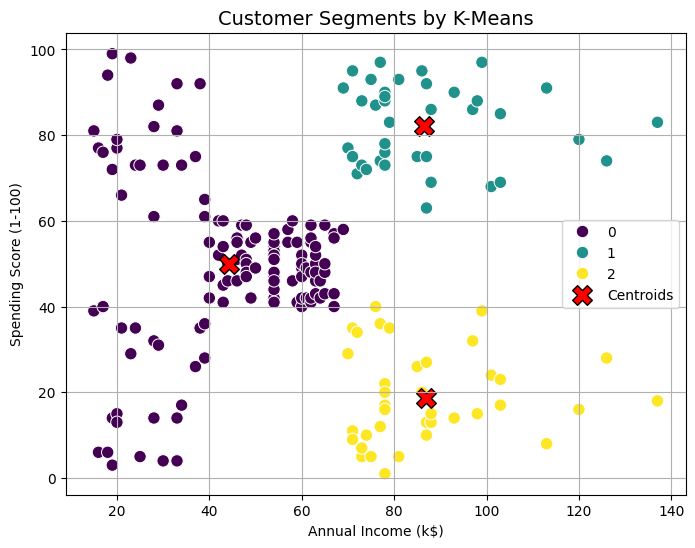

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the 'cluster' column is in df
df['cluster'] = pred

# Scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='cluster',            # Divide Cluster Color
    palette='viridis',
    data=df,                  # restoring scale : df
    s=80                      # Dot size
)

# Spotting Cluster Centroids (restoring original location before z-score)
centers_original = scaler.inverse_transform(model.cluster_centers_)
plt.scatter(
    centers_original[:, 0], centers_original[:, 1],
    c='red', s=200, marker='X', edgecolor='black', label='Centroids'
)

plt.title('Customer Segments by K-Means', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

### Dendrogram

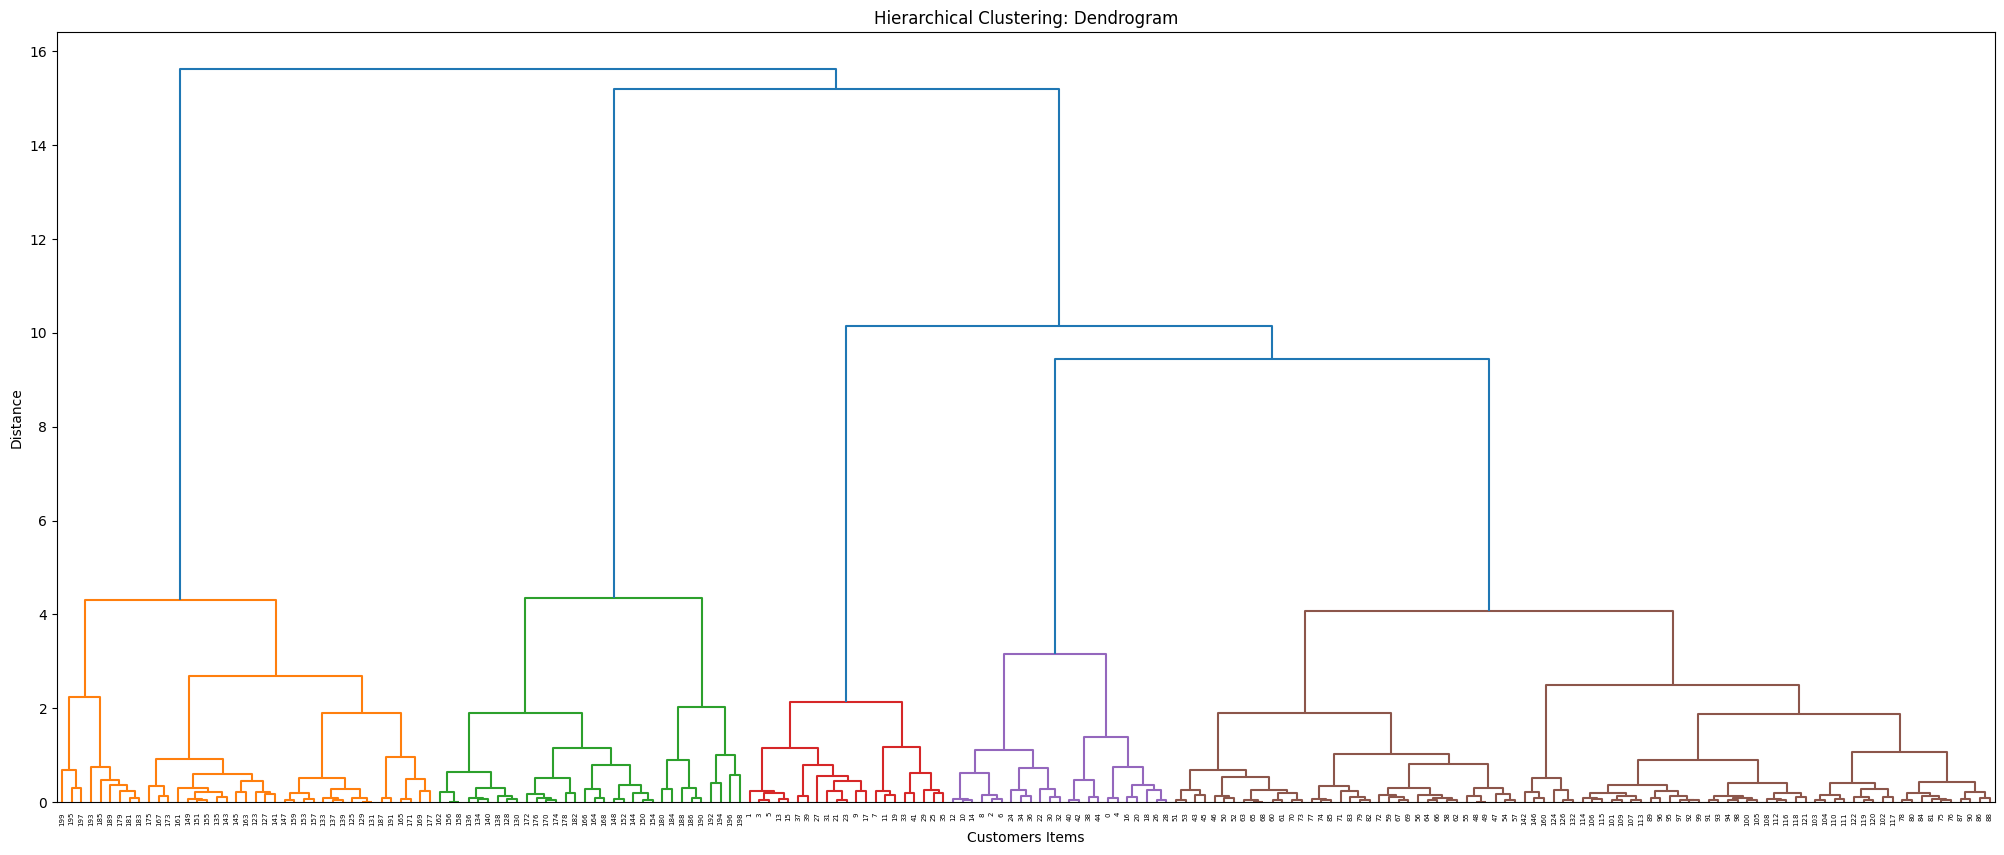

In [9]:
# Import dendrogram
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

# create dendrogram using ward linkage
Z = linkage(data, method='ward')

fig = plt.figure(figsize=(25, 10))
dendrogram(Z, color_threshold=Z[:,2].max()/2) # threshold is set by half of max value

# Set title of the plot
plt.title('Hierarchical Clustering: Dendrogram')
plt.xlabel('Customers Items')
plt.ylabel('Distance')
plt.show()

### Silhouette Score

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ensure df is loaded (copied from J2y_JgUtDgdz or mZnwYqPcF1Pz to make this cell self-contained)
df = pd.read_csv('https://raw.githubusercontent.com/wonseok-hong/DAP_TA/main/Mall_Customers.csv')

# Re-create data (copied from WdaDOXFLDkYe)
scaler = StandardScaler()
data = df[['Annual Income (k$)', 'Spending Score (1-100)']]
data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

# Re-run K-Means to get pred (copied from ICk4a5hrBRT4)
k = 3
model = KMeans(n_clusters=k, random_state=0, n_init='auto')
model.fit(data)
pred = model.predict(data)

print("Silhouette Coefficient:", silhouette_score(data, pred))

Silhouette Coefficient: 0.46658474419000145
